In [ ]:
import pandas as pd

df = pd.read_csv("housing.csv")

X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

df.shape
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [ ]:
X.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
ocean_proximity,0


In [ ]:
print(df.shape)

(20640, 10)


In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X["total_bedrooms"] = imputer.fit_transform(X[["total_bedrooms"]])

In [ ]:
X.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
ocean_proximity,0


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["ocean_proximity"]
numeric_features = X.columns.drop("ocean_proximity")

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

X_encoded = preprocessor.fit_transform(X)

encoded_feature_names = (
    preprocessor.named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
)

final_feature_names = list(encoded_feature_names) + list(numeric_features)

X_encoded = pd.DataFrame(
    X_encoded,
    columns=final_feature_names,
    index=X.index
)


In [ ]:
X_encoded.dtypes

,0
ocean_proximity_INLAND,float64
ocean_proximity_ISLAND,float64
ocean_proximity_NEAR BAY,float64
ocean_proximity_NEAR OCEAN,float64
longitude,float64
latitude,float64
housing_median_age,float64
total_rooms,float64
total_bedrooms,float64
population,float64


In [ ]:
import shap
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_encoded, y)


RandomForestRegressor(random_state=42)

In [1]:
from IPython.display import display, HTML

display(HTML("""
<h1 style="
    text-align:center;
    color:#BB1828;
    font-family:Arial;
    font-weight:bold;
">
Explanation by Feature relevance (SHAP)
</h1>
"""))

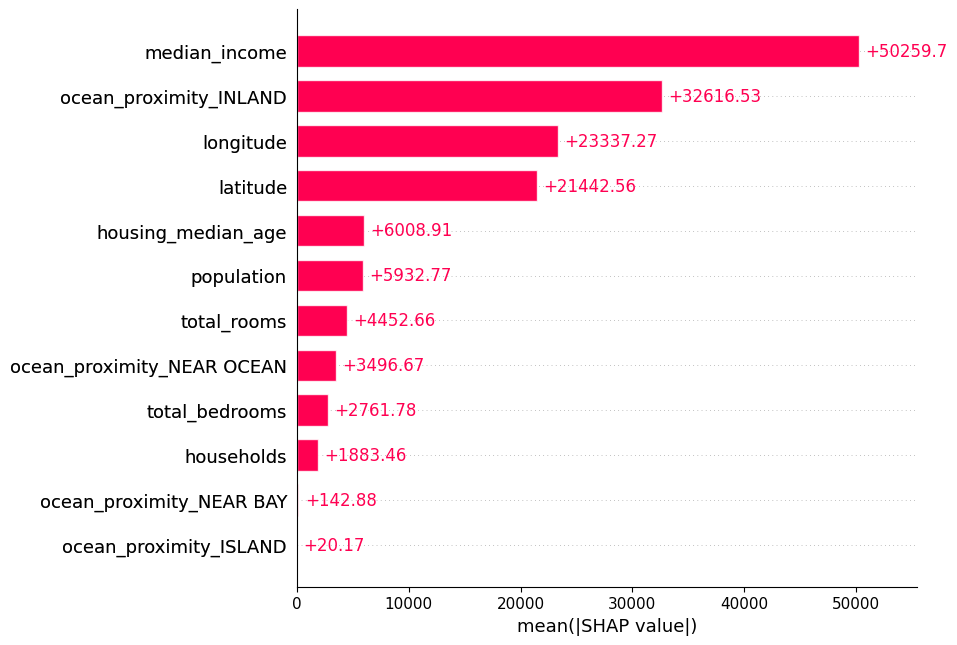

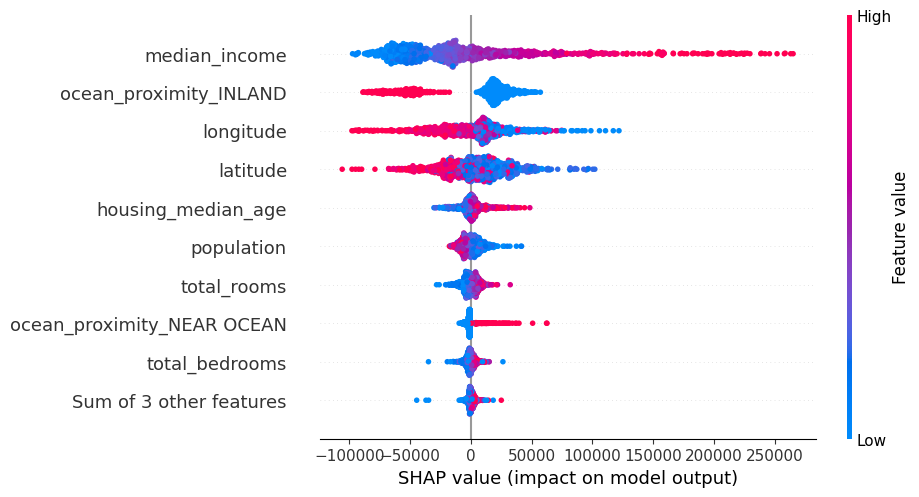

In [ ]:
import shap

# Prendre un échantillon pour accélérer
X_sample = X_encoded.sample(n=1000, random_state=42)

# Créer l'explainer pour RandomForest
explainer = shap.TreeExplainer(model)

# Calculer les SHAP values directement sur l'échantillon
shap_values = explainer(X_sample)  # ⚡ ceci renvoie un objet Explanation

# Graphique importance moyenne (bar chart)
shap.plots.bar(shap_values, max_display=15)

# Graphique beeswarm
shap.plots.beeswarm(shap_values)


In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt


In [2]:
from IPython.display import display, HTML

display(HTML("""
<h1 style="
    text-align:center;
    color:#BB1828;
    font-family:Arial;
    font-weight:bold;
">
Visual Explanation => PDP
</h1>
"""))

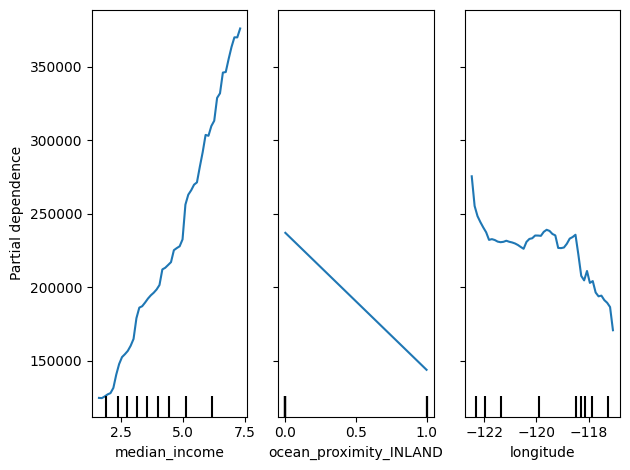

In [ ]:
pdp_features = [
    "median_income",
    "ocean_proximity_INLAND",
    "longitude"
]

PartialDependenceDisplay.from_estimator(
    model,
    X_encoded,
    features=pdp_features,
    grid_resolution=50
)

plt.tight_layout()
plt.show()
